In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
import numpy as np

import matplotlib.pyplot as plt

In [5]:
from sklearn.manifold import TSNE


In [4]:
simclr_embeddings = torch.load(
    "/kaggle/input/datasets/mehtab9000/embeddings/mae_embeddings.pt"
)

mae_embeddings = torch.load(
    "/kaggle/input/datasets/mehtab9000/embeddings/simclr_embeddings.pt"
)

print(simclr_embeddings.shape)
print(mae_embeddings.shape)

torch.Size([19186, 192])
torch.Size([19186, 512])


In [6]:
NUM_SAMPLES = 2000

indices = np.random.choice(
    len(simclr_embeddings),
    NUM_SAMPLES,
    replace=False
)

simclr_sample = simclr_embeddings[indices].numpy()

mae_sample = mae_embeddings[indices].numpy()

In [7]:
tsne_simclr = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

simclr_2d = tsne_simclr.fit_transform(
    simclr_sample
)

print(simclr_2d.shape)

(2000, 2)


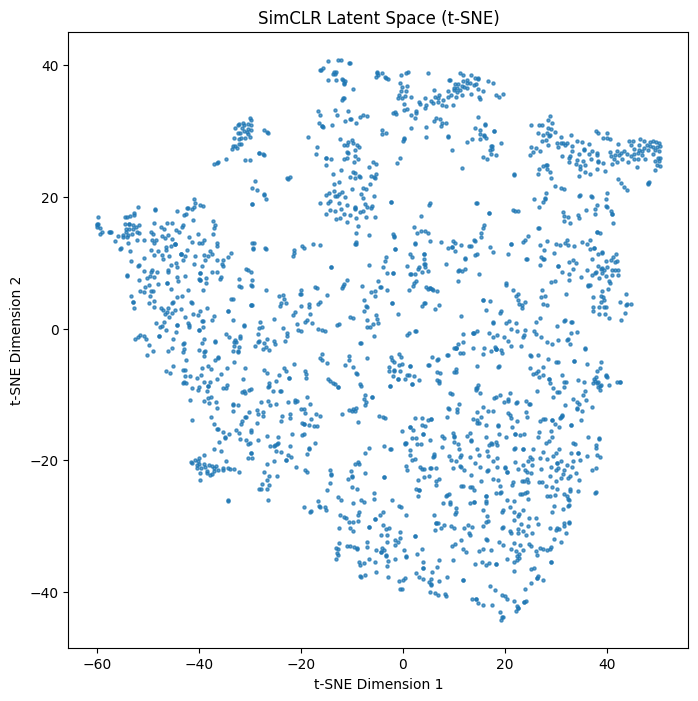

In [8]:
plt.figure(figsize=(8,8))

plt.scatter(
    simclr_2d[:,0],
    simclr_2d[:,1],
    s=5,
    alpha=0.7
)

plt.title("SimCLR Latent Space (t-SNE)")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

In [9]:
tsne_mae = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

mae_2d = tsne_mae.fit_transform(
    mae_sample
)

print(mae_2d.shape)

(2000, 2)


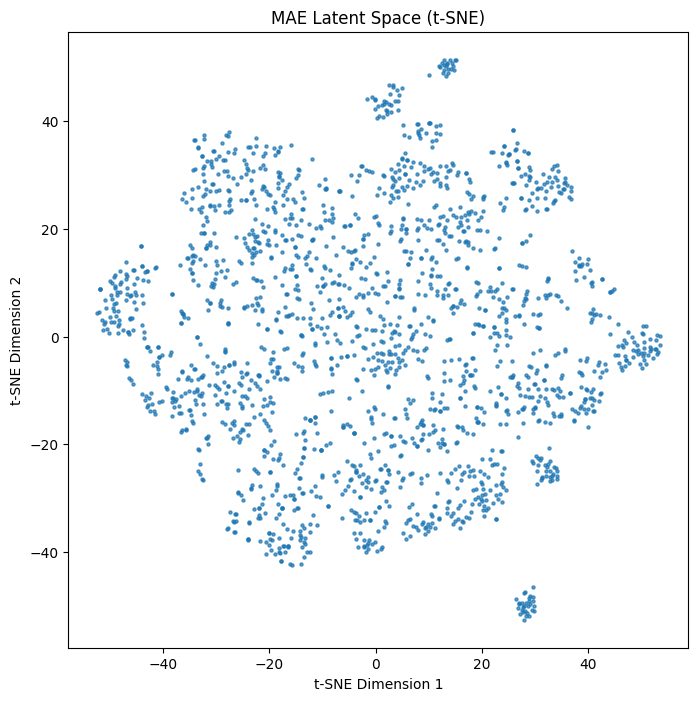

In [10]:
plt.figure(figsize=(8,8))

plt.scatter(
    mae_2d[:,0],
    mae_2d[:,1],
    s=5,
    alpha=0.7
)

plt.title("MAE Latent Space (t-SNE)")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

In [11]:
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

In [12]:
kmeans_simclr = KMeans(
    n_clusters=10,
    random_state=42
)

simclr_cluster_labels = kmeans_simclr.fit_predict(
    simclr_sample
)

In [13]:
simclr_silhouette = silhouette_score(
    simclr_sample,
    simclr_cluster_labels
)

simclr_db = davies_bouldin_score(
    simclr_sample,
    simclr_cluster_labels
)

print("SimCLR Silhouette Score:", simclr_silhouette)

print("SimCLR Davies-Bouldin Index:", simclr_db)

SimCLR Silhouette Score: 0.15711258
SimCLR Davies-Bouldin Index: 1.7317789034779594


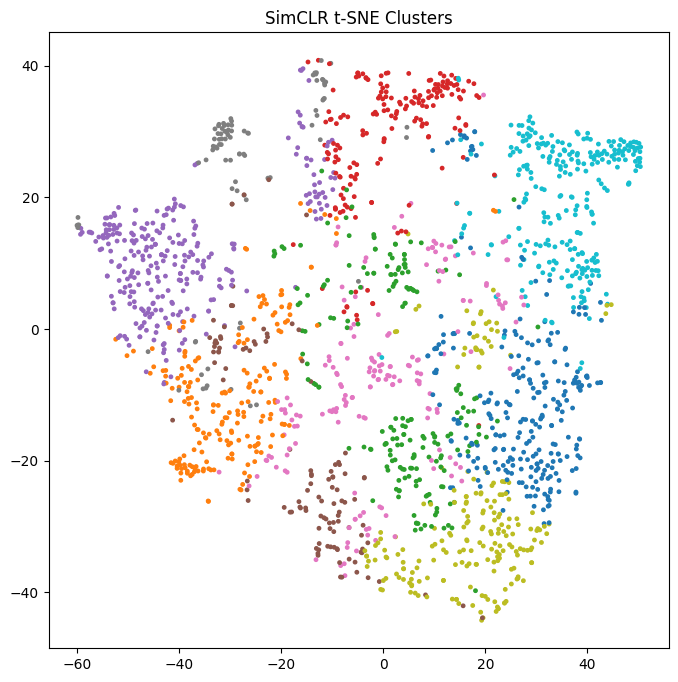

In [14]:
plt.figure(figsize=(8,8))

plt.scatter(
    simclr_2d[:,0],
    simclr_2d[:,1],
    c=simclr_cluster_labels,
    s=6,
    cmap="tab10"
)

plt.title("SimCLR t-SNE Clusters")

plt.show()

In [15]:
kmeans_mae = KMeans(
    n_clusters=10,
    random_state=42
)

mae_cluster_labels = kmeans_mae.fit_predict(
    mae_sample
)

In [16]:
mae_silhouette = silhouette_score(
    mae_sample,
    mae_cluster_labels
)

mae_db = davies_bouldin_score(
    mae_sample,
    mae_cluster_labels
)

print("MAE Silhouette Score:", mae_silhouette)

print("MAE Davies-Bouldin Index:", mae_db)

MAE Silhouette Score: 0.117600836
MAE Davies-Bouldin Index: 1.9722907812590922


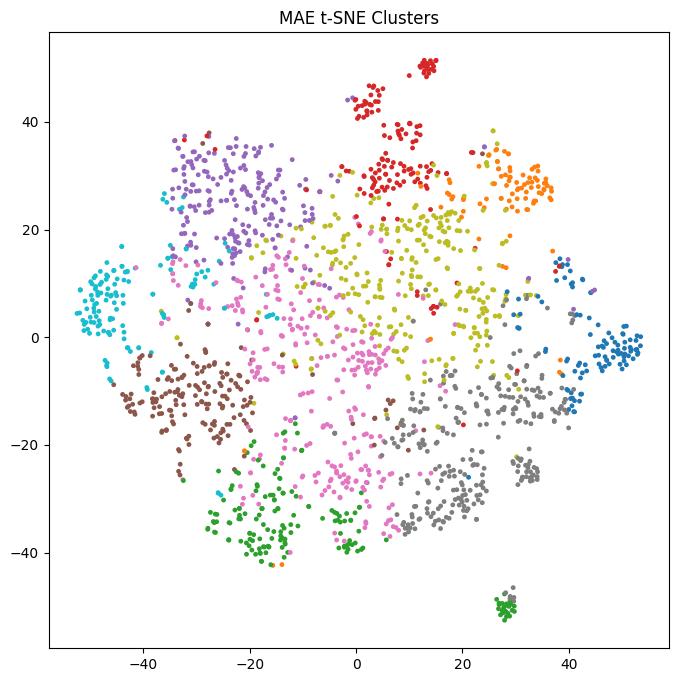

In [17]:
plt.figure(figsize=(8,8))

plt.scatter(
    mae_2d[:,0],
    mae_2d[:,1],
    c=mae_cluster_labels,
    s=6,
    cmap="tab10"
)

plt.title("MAE t-SNE Clusters")

plt.show()

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
simclr_np = simclr_embeddings.numpy()

mae_np = mae_embeddings.numpy()

In [21]:
import os

DATASET_PATH = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset"

TRAIN_IMAGE_PATH = os.path.join(
    DATASET_PATH,
    "train",
    "images"
)

print(TRAIN_IMAGE_PATH)

/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train/images


In [22]:
valid_extensions = (".jpg", ".jpeg", ".png")

simclr_paths = [
    os.path.join(TRAIN_IMAGE_PATH, img)
    for img in os.listdir(TRAIN_IMAGE_PATH)
    if img.lower().endswith(valid_extensions)
]

print(len(simclr_paths))

19186


In [23]:
query_idx = np.random.randint(0, len(indices))

real_idx = indices[query_idx]

query_path = simclr_paths[real_idx]

print(query_path)

/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train/images/IMG_00052.jpg


In [24]:
def retrieve_similar(
    embeddings,
    query_index,
    top_k=6
):

    similarities = cosine_similarity(
        embeddings[query_index].reshape(1, -1),
        embeddings
    )[0]

    nearest_indices = np.argsort(similarities)[::-1]

    return nearest_indices[:top_k]

In [25]:
simclr_neighbors = retrieve_similar(
    simclr_np,
    real_idx,
    top_k=6
)

print(simclr_neighbors)

[ 4043  3257  1945  7010 14538  2060]


In [26]:
mae_neighbors = retrieve_similar(
    mae_np,
    real_idx,
    top_k=6
)

print(mae_neighbors)

[ 4043  3257  3071  5489  4017 14099]


In [28]:
from PIL import Image
import matplotlib.pyplot as plt

def show_retrieval(indices_list, title):

    fig, axes = plt.subplots(
        1,
        len(indices_list),
        figsize=(15,5)
    )

    for i, idx in enumerate(indices_list):

        img_path = simclr_paths[idx]

        image = Image.open(img_path).convert("RGB")

        axes[i].imshow(image)

        if i == 0:
            axes[i].set_title("Query")
        else:
            axes[i].set_title(f"Rank {i}")

        axes[i].axis("off")

    plt.suptitle(title)

    plt.show()

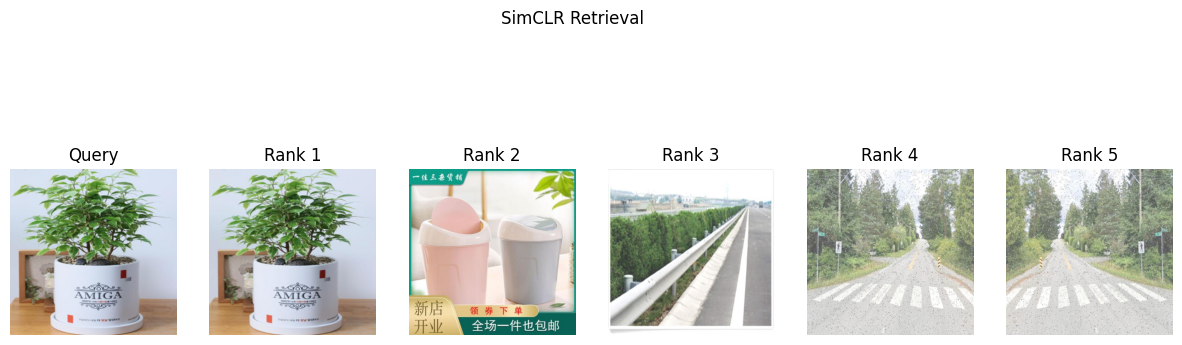

In [31]:
show_retrieval(
    simclr_neighbors,
    "SimCLR Retrieval"
)

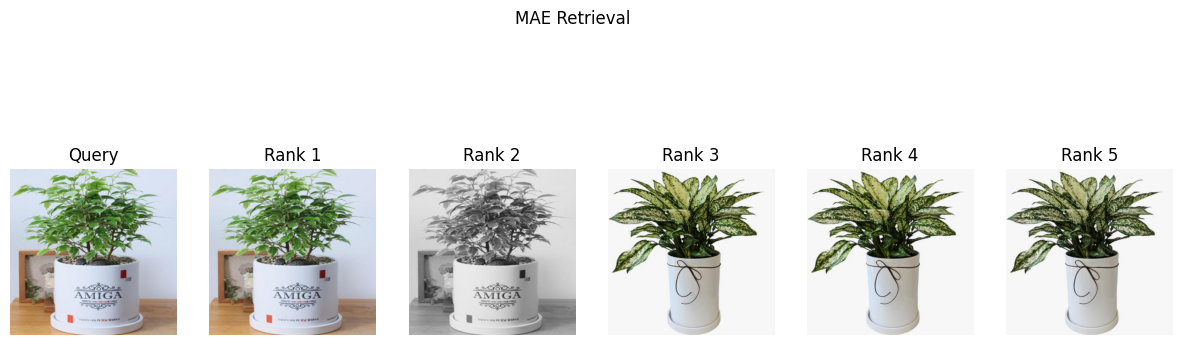

In [32]:
show_retrieval(
    mae_neighbors,
    "MAE Retrieval"
)

In [33]:
!pip install umap-learn -q

In [34]:
import umap.umap_ as umap

2026-06-02 10:35:00.689766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780396500.964527      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780396501.060804      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780396501.830434      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780396501.830481      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780396501.830484      58 computation_placer.cc:177] computation placer alr

In [35]:
umap_simclr = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

simclr_umap = umap_simclr.fit_transform(
    simclr_sample
)

print(simclr_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(2000, 2)


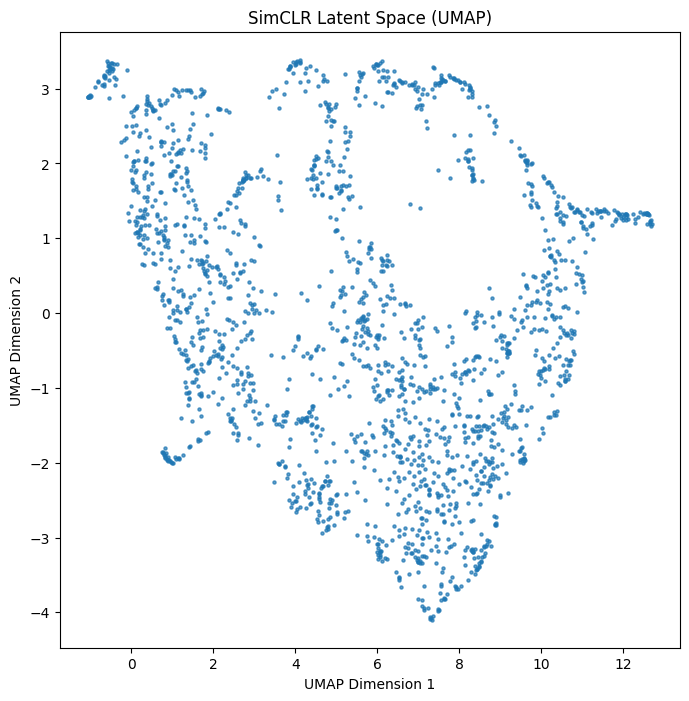

In [36]:
plt.figure(figsize=(8,8))

plt.scatter(
    simclr_umap[:,0],
    simclr_umap[:,1],
    s=5,
    alpha=0.7
)

plt.title("SimCLR Latent Space (UMAP)")

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

In [37]:
umap_mae = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

mae_umap = umap_mae.fit_transform(
    mae_sample
)

print(mae_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(2000, 2)


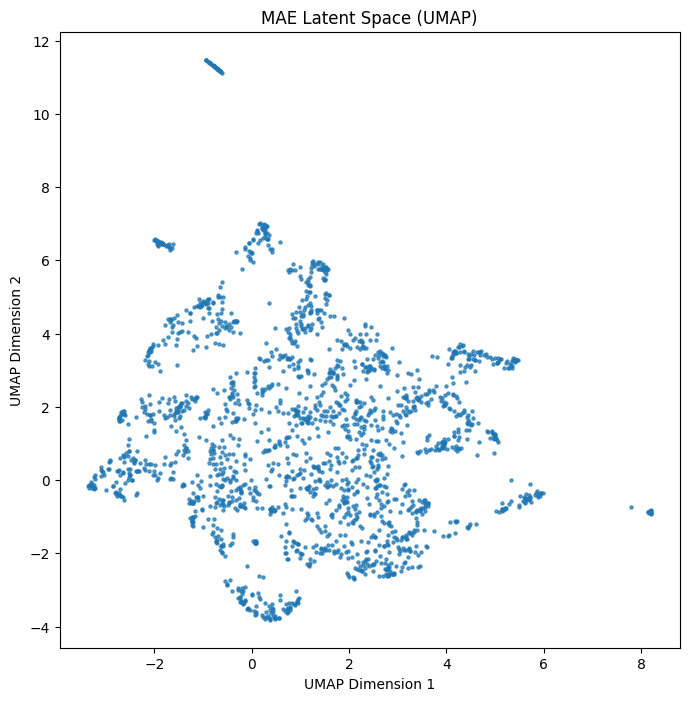

In [38]:
plt.figure(figsize=(8,8))

plt.scatter(
    mae_umap[:,0],
    mae_umap[:,1],
    s=5,
    alpha=0.7
)

plt.title("MAE Latent Space (UMAP)")

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()